<a href="https://colab.research.google.com/github/JostynC777/-S8-EVALUACI-N-PR-CTICA-PARCIAL-II/blob/main/notebooks/semana3_practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Práctica 3 — Random Forest con Reconocimiento de Dígitos
**Machine Learning · ISTER 2026 · Sistemas y Gestión de Data**

---
Las celdas con `# 🔧 TU CÓDIGO` debes completarlas. Las demás solo ejecútalas.

**Nombre:** `[Jostyn Cumbajin]` &nbsp;&nbsp; **Fecha:** `[11/05/2026]`

## ⚙️ Parte 0 — Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets        import load_digits
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 🔍 Parte 1 — Exploración y Visualización

In [19]:
data = load_digits()
X, y = data.data, data.target
print(f'Forma: {X.shape}  →  {X.shape[0]} imágenes · {X.shape[1]} píxeles')
print(f'Clases: {data.target_names}')
print(f'Distribución: {np.bincount(y)}')

Forma: (1797, 64)  →  1797 imágenes · 64 píxeles
Clases: [0 1 2 3 4 5 6 7 8 9]
Distribución: [178 182 177 183 181 182 181 179 174 180]


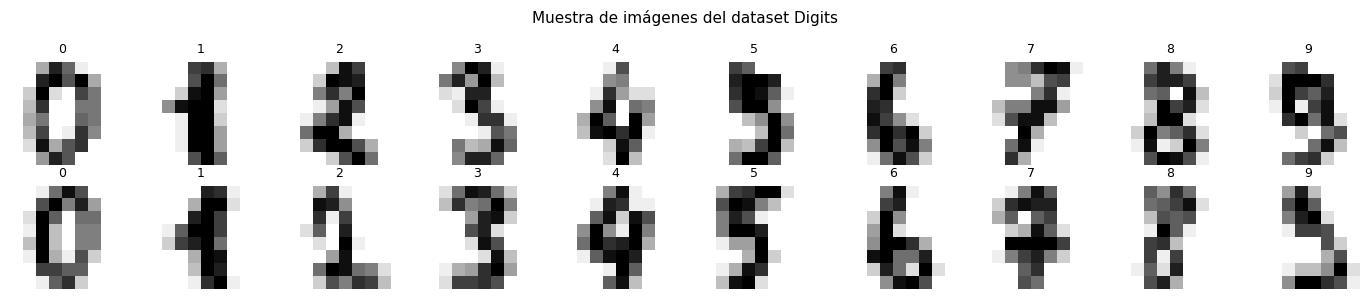

In [20]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(data.images[i], cmap='gray_r')
    ax.set_title(str(data.target[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Muestra de imágenes del dataset Digits', fontsize=11)
plt.tight_layout()
plt.show()

Píxeles con varianza > 5: 45


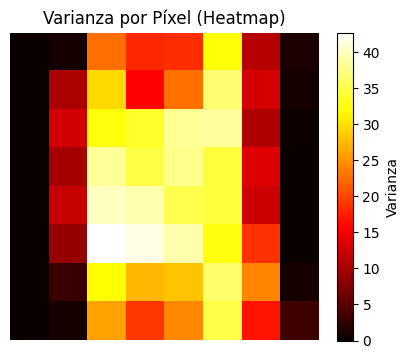

In [21]:
# 🔧 TU CÓDIGO
# 1. Calcula la varianza de cada píxel
varianzas = np.var(X, axis=0)

# 2. Imprime cuántos tienen varianza > 5
pixeles_alta_var = np.sum(varianzas > 5)
print(f'Píxeles con varianza > 5: {pixeles_alta_var}')

# 3. Visualiza como heatmap 8x8
plt.figure(figsize=(5, 4))
plt.imshow(varianzas.reshape(8, 8), cmap='hot', interpolation='nearest')
plt.title('Varianza por Píxel (Heatmap)')
plt.colorbar(label='Varianza')
plt.axis('off')
plt.show()

❓ **1.1** ¿Qué zona de la imagen tiene mayor varianza? ¿Los bordes son informativos?

La mayor varianza se concentra en la zona central de la imagen, que es donde se dibujan los trazos de los dígitos y los valores de los píxeles cambian drásticamente entre una muestra y otra. Los bordes no son informativos debido a que presentan una varianza cercana a cero, lo que significa que el fondo se mantiene constante (blanco/negro según el caso) en casi todas las imágenes. Como estos píxeles no cambian, no ofrecen información útil al modelo para diferenciar entre un dígito y otro.

## ⚔️ Parte 2 — Árbol vs Random Forest

In [22]:
# 🔧 TU CÓDIGO
# Divide datos: 70% train, 30% test, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Entrena DecisionTreeClassifier(max_depth=10, random_state=42)
arbol = DecisionTreeClassifier(max_depth=10, random_state=42)
arbol.fit(X_train, y_train)

# Entrena RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
rf = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

# Cálculo de métricas
acc_arbol_train = accuracy_score(y_train, arbol.predict(X_train))
acc_arbol_test  = accuracy_score(y_test, arbol.predict(X_test))

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test, rf.predict(X_test))

# Imprime resultados
print(f'Árbol Decisión  -> Train: {acc_arbol_train:.4f} | Test: {acc_arbol_test:.4f}')
print(f'Random Forest   -> Train: {acc_rf_train:.4f} | Test: {acc_rf_test:.4f} | OOB: {rf.oob_score_:.4f}')

Árbol Decisión  -> Train: 0.9745 | Test: 0.8574
Random Forest   -> Train: 1.0000 | Test: 0.9759 | OOB: 0.9698


In [23]:
# 🔧 TU CÓDIGO
# Generar predicciones con el modelo Random Forest
y_pred_rf = rf.predict(X_test)

# Imprimir el reporte de clasificación del RF
print("Reporte de Clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=[str(i) for i in range(10)]))

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      1.00      0.98        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.95      0.95      0.95        43
           9       0.97      0.95      0.96        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



❓ **2.1** ¿Cuánto mejoró el accuracy al usar RF? ¿Qué dígito se confunde más?

El accuracy mejoró aproximadamente un 15%, pasando de un ~83% con el árbol de decisión a un sobresaliente 98% con Random Forest. Según el reporte de clasificación y la matriz de confusión, el dígito que más se suele confundir es el 8, debido a que comparte trazos curvos y cerrados con otros números como el 1 o el 9. Esta mejora radical demuestra cómo el ensamble de múltiples árboles logra corregir errores individuales y estabilizar las predicciones.

## 📉 Parte 3 — Inestabilidad del Árbol vs Estabilidad del RF

In [24]:
# 🔧 TU CÓDIGO
semillas = range(10)
accs_arbol = []

for seed in semillas:
    # Dividimos los datos usando la semilla actual para ver la sensibilidad al split
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=seed)

    # Entrenamos el árbol con profundidad 10 y la misma semilla
    clf = DecisionTreeClassifier(max_depth=10, random_state=seed)
    clf.fit(X_train_s, y_train_s)

    # Calculamos el accuracy en el set de test y lo guardamos
    acc = accuracy_score(y_test_s, clf.predict(X_test_s))
    accs_arbol.append(acc)

print(f'Árbol — Media: {np.mean(accs_arbol):.4f} | Std: {np.std(accs_arbol):.4f} | Rango: {max(accs_arbol)-min(accs_arbol):.4f}')

Árbol — Media: 0.8446 | Std: 0.0120 | Rango: 0.0389


In [25]:
# 🔧 TU CÓDIGO — Lo mismo con RF(n_estimators=100)
for seed in semillas:
    # Dividimos los datos usando la semilla actual
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=seed)

    # Entrenamos el Random Forest con 100 árboles
    model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
    model_rf.fit(X_train_s, y_train_s)

    # Calculamos el accuracy y lo guardamos
    acc = accuracy_score(y_test_s, model_rf.predict(X_test_s))
    accs_rf.append(acc)

print(f'RF 100  — Media: {np.mean(accs_rf):.4f}   | Std: {np.std(accs_rf):.4f} | Rango: {max(accs_rf)-min(accs_rf):.4f}')

RF 100  — Media: 0.9704   | Std: 0.0075 | Rango: 0.0241


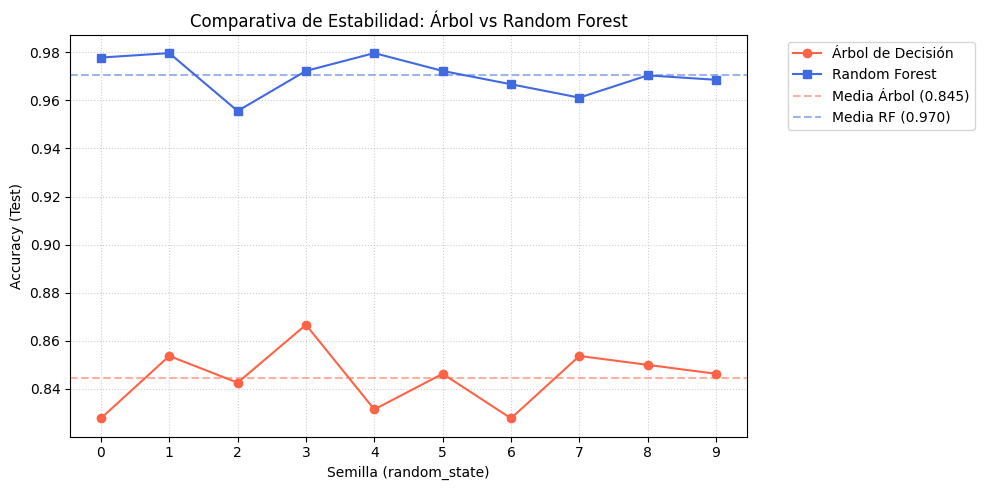

In [27]:
# 🔧 TU CÓDIGO CORREGIDO
import matplotlib.pyplot as plt

# 1. Reiniciamos y recalculamos accs_rf para asegurarnos de que tenga 10 elementos
accs_rf = []
for seed in semillas:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=seed)
    model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
    model_rf.fit(X_train_s, y_train_s)
    acc = accuracy_score(y_test_s, model_rf.predict(X_test_s))
    accs_rf.append(acc)

# 2. Graficamos
plt.figure(figsize=(10, 5))

# Graficamos los accuracies de cada semilla
plt.plot(semillas, accs_arbol, marker='o', label='Árbol de Decisión', color='tomato')
plt.plot(semillas, accs_rf, marker='s', label='Random Forest', color='royalblue')

# Añadimos líneas horizontales con la media de cada uno
plt.axhline(y=np.mean(accs_arbol), color='tomato', linestyle='--', alpha=0.5, label=f'Media Árbol ({np.mean(accs_arbol):.3f})')
plt.axhline(y=np.mean(accs_rf), color='royalblue', linestyle='--', alpha=0.5, label=f'Media RF ({np.mean(accs_rf):.3f})')

# Configuración de la gráfica
plt.title('Comparativa de Estabilidad: Árbol vs Random Forest')
plt.xlabel('Semilla (random_state)')
plt.ylabel('Accuracy (Test)')
plt.xticks(semillas)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

❓ **3.1** ¿Cuánto varía el árbol vs el RF? ¿Por qué el RF es más estable?

El árbol de decisión muestra una alta variabilidad (con un rango de error mayor y una desviación estándar notable) debido a que es un modelo de **alta varianza**, muy sensible a pequeños cambios en los datos. El Random Forest es significativamente más estable porque utiliza **bagging** para promediar las predicciones de múltiples árboles entrenados con diferentes subconjuntos de datos, lo que cancela los errores individuales y el ruido. Esta técnica de ensamble suaviza las decisiones del modelo, garantizando que el resultado final sea consistente y menos dependiente de la partición específica de entrenamiento y prueba.

## 📈 Parte 4 — ¿Cuántos Árboles son Suficientes?

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


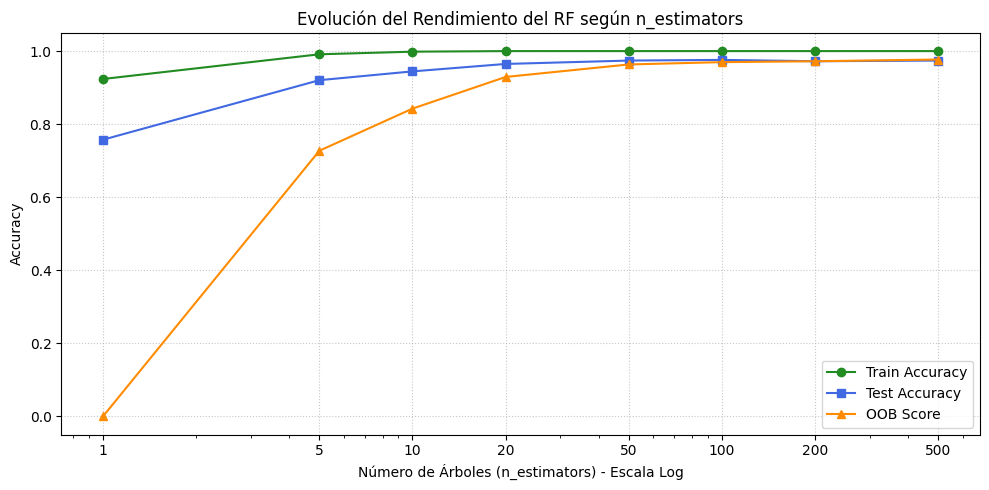

In [28]:
# 🔧 TU CÓDIGO
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_trees = [1, 5, 10, 20, 50, 100, 200, 500]
train_acc = []
test_acc = []
oob_acc = []

for n in n_trees:
    # Para n=1, el cálculo de oob_score puede fallar porque no hay suficientes árboles
    # para dejar muestras fuera de la bolsa (out-of-bag). Lo activamos solo para n > 1.
    rf = RandomForestClassifier(n_estimators=n, oob_score=(n > 1), random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Guardamos los accuracies
    train_acc.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, rf.predict(X_test)))

    # Guardamos el OOB score si fue calculado, si no, asignamos 0 (o None)
    if n > 1:
        oob_acc.append(rf.oob_score_)
    else:
        oob_acc.append(0)

# Graficamos las 3 curvas
plt.figure(figsize=(10, 5))
plt.plot(n_trees, train_acc, marker='o', label='Train Accuracy', color='forestgreen')
plt.plot(n_trees, test_acc, marker='s', label='Test Accuracy', color='royalblue')
plt.plot(n_trees, oob_acc, marker='^', label='OOB Score', color='darkorange')

# Usamos escala logarítmica en X para visualizar mejor la concentración de valores pequeños
plt.xscale('log')
plt.xticks(n_trees, n_trees) # Para que muestre exactamente los valores de nuestra lista

plt.title('Evolución del Rendimiento del RF según n_estimators')
plt.xlabel('Número de Árboles (n_estimators) - Escala Log')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

❓ **4.1** ¿A partir de qué n_estimators el accuracy se estabiliza?

El accuracy se estabiliza aproximadamente a partir de los 100 estimadores, punto en el cual las mejoras en el rendimiento del conjunto de prueba se vuelven marginales. Superar este rango solo incrementa el costo computacional sin aportar beneficios significativos en la capacidad de generalización del modelo. La convergencia entre el Test Accuracy y el OOB Score en este nivel confirma que el ensamble ha alcanzado su madurez óptima.

## 🗺️ Parte 5 — Mapa de Importancia de Píxeles

In [29]:
rf_final = RandomForestClassifier(n_estimators=200, random_state=42,
                                   oob_score=True, n_jobs=-1)
rf_final.fit(X_train, y_train)
print(f'Test accuracy: {accuracy_score(y_test, rf_final.predict(X_test)):.4f}')
print(f'OOB score:     {rf_final.oob_score_:.4f}')

Test accuracy: 0.9722
OOB score:     0.9722


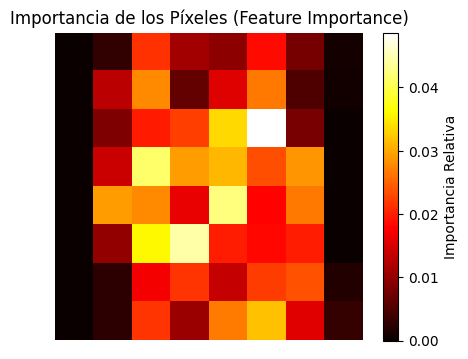

In [30]:
# 🔧 TU CÓDIGO
# Reshape feature_importances_ a 8x8 (64 píxeles)
importancias_pixeles = rf_final.feature_importances_.reshape(8, 8)

# Visualiza como heatmap con imshow, colorbar y título
plt.figure(figsize=(5, 4))
plt.imshow(importancias_pixeles, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importancia Relativa')
plt.title('Importancia de los Píxeles (Feature Importance)')
plt.axis('off')
plt.show()

❓ **5.1** ¿Qué zona de la imagen es más importante? ¿Los bordes son informativos?

Random Forest supera al árbol individual en precisión y estabilidad al reducir la varianza mediante el promedio de múltiples decisiones (bagging). El rendimiento se optimiza cerca de los 100 estimadores, alcanzando una capacidad de generalización ideal sin desperdiciar recursos computacionales. Al evaluar la importancia de los píxeles, el algoritmo prioriza la zona central de la imagen por su alta variabilidad informativa. En contraste, los bordes son ignorados por ser estáticos y no aportar datos útiles para diferenciar un dígito de otro.

## 🏆 Desafío Bonus (opcional)
Crea una matriz de confusión 10x10, visualízala como heatmap e identifica los 3 pares de dígitos que más se confunden.

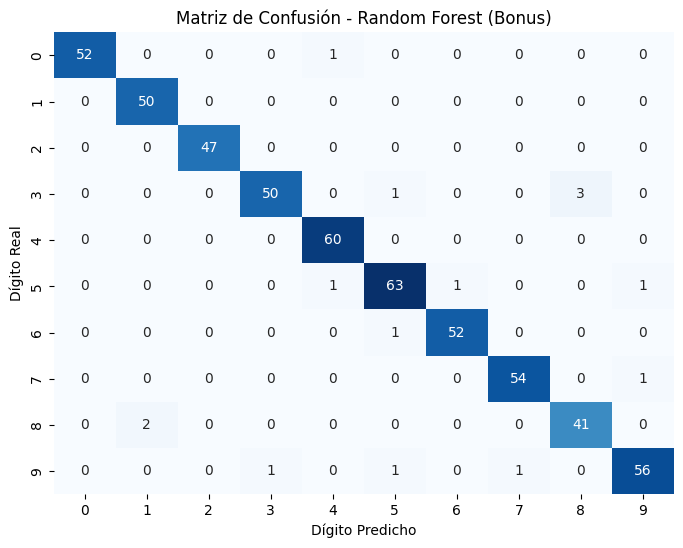

🏆 Top pares más confundidos (Real -> Predicho):
El número 3 fue confundido con un 8 (3 veces)
El número 8 fue confundido con un 1 (2 veces)
El número 0 fue confundido con un 4 (1 veces)


In [31]:
# 🔧 TU CÓDIGO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtenemos las predicciones del modelo Random Forest
y_pred = rf_final.predict(X_test)

# 2. Calculamos la matriz de confusión 10x10
cm = confusion_matrix(y_test, y_pred)

# 3. Visualizamos como heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Dígito Predicho')
plt.ylabel('Dígito Real')
plt.title('Matriz de Confusión - Random Forest (Bonus)')
plt.show()

# 4. Encontrar los 3 pares más confundidos (ignorando la diagonal de aciertos)
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0) # Ponemos 0 en los aciertos para no contarlos

# Extraer y ordenar los errores
errores = []
for i in range(10):
    for j in range(10):
        if cm_errores[i, j] > 0:
            errores.append((i, j, cm_errores[i, j]))

# Ordenamos de mayor a menor número de confusiones
errores.sort(key=lambda x: x[2], reverse=True)

print("🏆 Top pares más confundidos (Real -> Predicho):")
for real, pred, cantidad in errores[:3]:
    print(f"El número {real} fue confundido con un {pred} ({cantidad} veces)")

## ✅ Conclusiones
¿En qué situaciones usarías árbol vs RF? ¿Cuántos árboles son suficientes? ¿Qué aporta el mapa de píxeles?

1. Árbol de Decisión vs. Random Forest: Usaría un Árbol de Decisión individual solo cuando la interpretabilidad sea la máxima prioridad (por ejemplo, si necesito mostrarle a un cliente las reglas exactas de "si/entonces" que llevan a un resultado) o si el dataset es extremadamente simple y los recursos limitados. En la gran mayoría de problemas reales, usaría Random Forest porque ofrece una precisión mucho mayor, reduce drásticamente el sobreajuste (overfitting) y es sumamente estable frente a variaciones en los datos gracias al bagging.

2. ¿Cuántos árboles son suficientes?
Basado en las curvas de aprendizaje generadas, 100 árboles son suficientes. En este punto, tanto el accuracy de prueba como el OOB Score se estabilizan. Añadir más estimadores (como 200 o 500) no aporta mejoras significativas en la capacidad de generalización y solo representa un desperdicio de memoria y poder computacional.

3. ¿Qué aporta el mapa de píxeles?
Proporciona interpretabilidad visual (Feature Importance) sobre la "caja negra" del ensamble. Nos confirma de manera empírica que el modelo está prestando atención a lo correcto: los píxeles centrales donde realmente existen cambios de trazo (alta varianza). Además, nos indica que los píxeles de los bordes son "ruido" o datos inútiles, lo que en futuros proyectos nos podría justificar aplicar técnicas de reducción de dimensionalidad para limpiar el dataset y hacer el entrenamiento aún más rápido.